In [111]:
import pandas as pd
import numpy as np
import yaml
import pypsa
import matplotlib.pyplot as plt
from pathlib import Path

In [112]:
with open(Path.cwd().parent / 'config.basicrun.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [66]:
import requests
import pandas as pd

# --- Eurostat query settings ---
DATASET = "nrg_bal_c"
GEO = "EU27_2020"
TIME = "2024"
SIEC = "G3000"      # Natural gas :contentReference[oaicite:3]{index=3}
UNIT = "TJ"         # Terajoule (energy content basis as provided by the balance)

BCM_TO_TWH = 10.5

# Eurostat balance items (nrg_bal) for your sectoral split :contentReference[oaicite:4]{index=4}
SECTORS = [
    ("Power sector (input to electricity & heat generation)", "TI_EHG_E"),
    ("Residential heating (households)", "FC_OTH_HH_E"),
    ("Services heating (commercial & public services)", "FC_OTH_CP_E"),
    ("Industry heating (energy use)", "FC_IND_E"),
    ("Industry feedstock (non-energy use)", "FC_IND_NE"),
]

BASE_URL = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{DATASET}"

def fetch_one(nrg_bal_code: str) -> float:
    params = {
        "geo": GEO,
        "time": TIME,
        "siec": SIEC,
        "unit": UNIT,
        "nrg_bal": nrg_bal_code,
        "lang": "EN",
        "format": "JSON",
    }
    r = requests.get(BASE_URL, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    # JSON-stat: values are in js["value"], typically a dict {index: value}
    values = js.get("value", {})
    if not values:
        return float("nan")

    # There should be exactly 1 observation given the tight filters
    v = next(iter(values.values()))
    return float(v) if v is not None else float("nan")

rows = []
for sector_label, code in SECTORS:
    tj = fetch_one(code)
    rows.append({
        "sector": sector_label,
        "nrg_bal": code,
        "geo": GEO,
        "time": int(TIME),
        "unit": UNIT,
        "siec": SIEC,
        "value_TJ": tj,
        "value_TWh": tj / 3600.0,   # 1 TWh = 3600 TJ
    })

df = pd.DataFrame(rows)

# Convenience aggregates matching your requested buckets
df_agg_eu = pd.DataFrame([
    {
        "sector": "Power sector",
        "value_TJ": df.loc[df["nrg_bal"].eq("TI_EHG_E"), "value_TJ"].sum(),
    },
    {
        "sector": "Residential + Services heating",
        "value_TJ": df.loc[df["nrg_bal"].isin(["FC_OTH_HH_E", "FC_OTH_CP_E"]), "value_TJ"].sum(),
    },
    {
        "sector": "Industry heating",
        "value_TJ": df.loc[df["nrg_bal"].eq("FC_IND_E"), "value_TJ"].sum(),
    },
    {
        "sector": "Industry feedstock",
        "value_TJ": df.loc[df["nrg_bal"].eq("FC_IND_NE"), "value_TJ"].sum(),
    },
])
df_agg_eu["value_TWh"] = df_agg_eu["value_TJ"] / 3600.0
df_agg_eu["geo"] = GEO
df_agg_eu["time"] = int(TIME)
df_agg_eu["unit"] = "TJ/TWh"
df_agg_eu

# You now have:
# - df: raw-by-balance-item view (with Eurostat codes)
# - df_agg: exactly your 4 sector buckets

,sector,value_TJ,value_TWh,geo,time,unit
0,Power sector,3453718.704,959.366307,EU27_2020,2024,TJ/TWh
1,Residential + Services heating,4073380.347,1131.494541,EU27_2020,2024,TJ/TWh
2,Industry heating,2865468.523,795.963479,EU27_2020,2024,TJ/TWh
3,Industry feedstock,458571.765,127.381046,EU27_2020,2024,TJ/TWh


In [67]:
# Hard-coded dataframe with the specified values
df_agg_uk = pd.DataFrame([
    {
        "sector": "Power sector",
        "value_TJ": np.nan,
        "value_TWh": 206.,
        "geo": "UK",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Residential + Services heating",
        "value_TJ": np.nan,
        "value_TWh": 345,
        "geo": "UK",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Industry heating",
        "value_TJ": np.nan,
        "value_TWh": 85.,
        "geo": "UK",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Industry feedstock",
        "value_TJ": np.nan,
        "value_TWh": 0.,
        "geo": "UK",
        "time": 2024,
        "unit": "TJ/TWh"
    }
])

df_agg_uk

,sector,value_TJ,value_TWh,geo,time,unit
0,Power sector,NaN,206.0,UK,2024,TJ/TWh
1,Residential + Services heating,NaN,345.0,UK,2024,TJ/TWh
2,Industry heating,NaN,85.0,UK,2024,TJ/TWh
3,Industry feedstock,NaN,0.0,UK,2024,TJ/TWh


In [68]:
df_agg_no = pd.DataFrame([
    {
        "sector": "Power sector",
        "value_TJ": np.nan,
        "value_TWh": 0.,  # Not separately reported in SSB data
        "geo": "Norway",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Residential + Services heating",
        "value_TJ": np.nan,
        "value_TWh": 0.,  # Not separately reported in SSB data
        "geo": "Norway",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Industry heating",
        "value_TJ": np.nan,
        "value_TWh": 2.5,  # Manufacturing etc.
        "geo": "Norway",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Industry feedstock",
        "value_TJ": np.nan,
        "value_TWh": 1.5,  # Non energy consumption
        "geo": "Norway",
        "time": 2024,
        "unit": "TJ/TWh"
    }
])

df_agg_ch = pd.DataFrame([
    {
        "sector": "Total",
        "value_TJ": np.nan,
        "value_TWh": 26.5,
        "geo": "Switzerland",
        "time": 2024,
        "unit": "TJ/TWh"
    },
])

# Source notes:
# NORWAY (SSB energy balance table excerpt)
# Natural gas:
#   - Final consumption (11+12): 5.4 TWh
#   - Non energy consumption:    1.5 TWh
#   - Final energy consumption:  3.9 TWh
#   - Manufacturing etc.:        2.5 TWh
#   - Transport:                1.2 TWh
# (All from SSB "Supply and use of energy in Norway by energy product, Energy balance. TWh" for 2024)
# https://www.ssb.no/en/energi-og-industri/energi/statistikk/produksjon-og-forbruk-av-energi-energibalanse-og-energiregnskap  (StatBank table 11561)

# SWITZERLAND (SFOE extract, "Energy Consumption in Switzerland 2024")
# Gas final consumption (2024): 26.522 TWh (95'480 TJ)
# Gas used for district heating & electricity production: 1.825 TWh
# Imports of natural gas (2024): 27.911 TWh (100'480 TJ)
# https://pubdb.bfe.admin.ch/en/publication/download/12195

In [69]:
df = pd.concat([df_agg_eu, df_agg_uk, df_agg_no, df_agg_ch])

In [70]:
df

,sector,value_TJ,value_TWh,geo,time,unit
0,Power sector,3453718.704,959.366307,EU27_2020,2024,TJ/TWh
1,Residential + Services heating,4073380.347,1131.494541,EU27_2020,2024,TJ/TWh
2,Industry heating,2865468.523,795.963479,EU27_2020,2024,TJ/TWh
3,Industry feedstock,458571.765,127.381046,EU27_2020,2024,TJ/TWh
0,Power sector,NaN,206.000000,UK,2024,TJ/TWh
1,Residential + Services heating,NaN,345.000000,UK,2024,TJ/TWh
2,Industry heating,NaN,85.000000,UK,2024,TJ/TWh
3,Industry feedstock,NaN,0.000000,UK,2024,TJ/TWh
0,Power sector,NaN,0.000000,Norway,2024,TJ/TWh
1,Residential + Services heating,NaN,0.000000,Norway,2024,TJ/TWh


##### RePowerEU

In [71]:
reference_eu27_total_2019 = 3918 / BCM_TO_TWH
eu27_total_2024 = df.loc[df.geo == 'EU27_2020', 'value_TWh'].sum() / BCM_TO_TWH

already_done = reference_eu27_total_2019 - eu27_total_2024
print(already_done)

86.0756788624339


In [72]:
rows = [
    # Fit-for-55
    {
        "timing": "Ff55 savings by 2030",
        "measure": "Total of all Fit-for-55 measures",
        "bcm_2030": 116.0 - already_done,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": np.nan,
        "justification": "Fit-for-55 modelling estimates 30% natural gas savings",
        "eligibility_eu_programmes": "-",
    },
    # Short-term preparedness
    {
        "timing": "Short-term preparedness",
        "measure": "Diversification (additional LNG using existing infrastructure)",
        "bcm_2030": 50.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": np.nan,
        "justification": "RePowerEU Communication COM(2022) 108 final",
        "eligibility_eu_programmes": "-",
    },
    {
        "timing": "Short-term preparedness",
        "measure": "Diversification of pipeline imports using existing infrastructure",
        "bcm_2030": 10.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": np.nan,
        "justification": (
            "In 2030, long term contracts account for about 110 bcm "
            "(of which about 55 bcm are take-or-pay contracts)"
        ),
        "eligibility_eu_programmes": "-",
    },
    {
        "timing": "Short-term preparedness",
        "measure": "Delayed phase-out and more operating hours for coal",
        "bcm_2030": 24.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": 2.0,
        "justification": (
            "Using existing capacity. The investment refers to CAPEX. "
            "The fuel cost (coal) is not included (OPEX). "
            "The total expenditure of the switch from gas to coal is the sum of CAPEX and OPEX."
        ),
        "eligibility_eu_programmes": "-",
    },
    {
        "timing": "Short-term preparedness",
        "measure": "Abandoned phase-out nuclear plants",
        "bcm_2030": 7.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": np.nan,
        "justification": "Recent political decisions in BE and FR",
        "eligibility_eu_programmes": "-",
    },
    {
        "timing": "Short-term preparedness",
        "measure": "Fuel switch in the residential and service sectors",
        "bcm_2030": 9.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": np.nan,
        "justification": "Fuel switch driven by price changes",
        "eligibility_eu_programmes": "-",
    },
    {
        "timing": "Short-term preparedness",
        "measure": "EU Save: Demand measures (behaviour)",
        "bcm_2030": 10.0,  # shown as (10) in table
        "bcm_in_brackets": True,
        "investments_bn_eur_2022_2030": np.nan,
        "justification": (
            "Measure 9 of the IEA plan on gas in the EU "
            "(gas saving counted under energy efficiency)"
        ),
        "eligibility_eu_programmes": "-",
    },
    {
        "timing": "Short-term preparedness",
        "measure": "EU Save: Industry curtailment",
        "bcm_2030": np.nan,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": np.nan,
        "justification": "Emergency measure",
        "eligibility_eu_programmes": "-",
    },
    # Mid-term (until 2027)
    {
        "timing": "Mid-term (until 2027)",
        "measure": "New LNG infrastructure and pipeline corridors",
        "bcm_2030": np.nan,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": 10.0,
        "justification": (
            "These infrastructure and pipelines facilitate the full effect of the diversification. "
            "Compared to average EU LNG imports of 7 bcm/month (in 2019-21), the EU system could "
            "absorb an additional 3.8 bcm/month (45.6 bcm/year) of LNG if bottlenecks are removed. "
            "However, there are currently only 8 to 10 available Floating Storage Regassification Units LNG terminals in the world."
        ),
        "eligibility_eu_programmes": "Modernisation Fund, RRF, CEF, ERDF and CF, for projects on the 5th PCI list",
    },
    {
        "timing": "Mid-term (until 2027)",
        "measure": "Additional investments in the power grid and storage",
        "bcm_2030": np.nan,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": 39.0,
        "justification": "The storage is about 10bn.",
        "eligibility_eu_programmes": "CEF, InvestEU, HE, ERDF, CF, JTF, RRF, ETF Funds",
    },
    {
        "timing": "Mid-term (until 2027)",
        "measure": "Biomass in power generation",
        "bcm_2030": 1.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": 2.0,
        "justification": "In line with the sustainability criteria of the Renewable Energy Directive.",
        "eligibility_eu_programmes": "HE, InvestEU, LIFE, ERDF, CF, JTF, RRF, ETS Funds, RES EU FM, EAFRD",
    },
    {
        "timing": "Mid-term (until 2027)",
        "measure": "Energy Efficiency and Heat Pumps",
        "bcm_2030": 37.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": 56.0,
        "justification": "Incl. Energy efficiency in buildings; Lower final electricity demand;",
        "eligibility_eu_programmes": "HE, InvestEU, LIFE, ERDF, CF, JTF, RRF, ETS Funds",
    },
    {
        "timing": "Mid-term (until 2027)",
        "measure": "PV and wind",
        "bcm_2030": 21.0,  # shown as (21) bcm, see justification
        "bcm_in_brackets": True,
        "investments_bn_eur_2022_2030": 86.0,
        "justification": (
            "In the scenario, about 12 bcm is achieved trough almost 4Mt of additional domestic hydrogen production "
            "and 9 bcm through additional substitution of gas in the power system. "
            "These bcm savings are distributed across the other sectors in the table."
        ),
        "eligibility_eu_programmes": "HE, InvestEU, CEF, LIFE, ERDF, CF, JTF, RRF, ETS Funds, RES EU FM",
    },
    {
        "timing": "Mid-term (until 2027)",
        "measure": "Sustainable bio-methane",
        "bcm_2030": 17.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": 37.0,
        "justification": (
            "Increased use in households, industry and agriculture. "
            "The total (with Fit for 55) adds up to 35 bcm in 2030."
        ),
        "eligibility_eu_programmes": "InvestEU, ERDF, CF, JTF, CEF, ETS Funds, EAFRD",
    },
    {
        "timing": "Mid-term (until 2027)",
        "measure": "Reduced use in industry",
        "bcm_2030": 12.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": 41.0,
        "justification": (
            "Incl. Electrification, energy efficiency, and fuel substitution (incl. hydrogen); "
            "Excl. the cost of production of hydrogen and biogas/bio-methane; Excl. refineries."
        ),
        "eligibility_eu_programmes": "HE, ETS Funds, InvestEU, ERDF, CF, RRF",
    },
    {
        "timing": "Mid-term (until 2027)",
        "measure": "UK reduction across sectors",
        "bcm_2030": 110.0 / BCM_TO_TWH,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": np.nan,
        "justification": "UK will reduce by 2030 by 110TWh according to FES 25 Holistic Transition across sectors",
        "eligibility_eu_programmes": "",
    },
    # Long-term needs (by 2027 & beyond)
    {
        "timing": "Long-term needs (by 2027 & beyond)",
        "measure": "Renewable hydrogen (domestic and import)",
        "bcm_2030": 27.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": 27.0,
        "justification": "€27 bn is direct investment in electrolysers and distribution of hydrogen in the EU.",
        "eligibility_eu_programmes": "CEF, InvestEU, HE, ETS Funds, RRF, ERDF, CF, JTF",
    },
    # Total
    {
        "timing": "Total",
        "measure": "Total",
        "bcm_2030": 310.0,
        "bcm_in_brackets": False,
        "investments_bn_eur_2022_2030": 300.0,
        "justification": (
            "Note: bcm figures in brackets are provided for information but not included in the total."
        ),
        "eligibility_eu_programmes": "",
    },
]

df_f55_rpe = pd.DataFrame(rows)
df_f55_rpe.insert(0, "row_id", range(1, len(df_f55_rpe) + 1))

df_f55_rpe['twh_2030'] = df_f55_rpe['bcm_2030'] * BCM_TO_TWH
df_f55_rpe

,row_id,timing,measure,bcm_2030,bcm_in_brackets,investments_bn_eur_2022_2030,justification,eligibility_eu_programmes,twh_2030
0,1,Ff55 savings by 2030,Total of all Fit-for-55 measures,29.924321,False,NaN,Fit-for-55 modelling estimates 30% natural gas...,-,314.205372
1,2,Short-term preparedness,Diversification (additional LNG using existing...,50.000000,False,NaN,RePowerEU Communication COM(2022) 108 final,-,525.000000
2,3,Short-term preparedness,Diversification of pipeline imports using exis...,10.000000,False,NaN,"In 2030, long term contracts account for about...",-,105.000000
3,4,Short-term preparedness,Delayed phase-out and more operating hours for...,24.000000,False,2.0,Using existing capacity. The investment refers...,-,252.000000
4,5,Short-term preparedness,Abandoned phase-out nuclear plants,7.000000,False,NaN,Recent political decisions in BE and FR,-,73.500000
5,6,Short-term preparedness,Fuel switch in the residential and service sec...,9.000000,False,NaN,Fuel switch driven by price changes,-,94.500000
6,7,Short-term preparedness,EU Save: Demand measures (behaviour),10.000000,True,NaN,Measure 9 of the IEA plan on gas in the EU (ga...,-,105.000000
7,8,Short-term preparedness,EU Save: Industry curtailment,NaN,False,NaN,Emergency measure,-,NaN
8,9,Mid-term (until 2027),New LNG infrastructure and pipeline corridors,NaN,False,10.0,These infrastructure and pipelines facilitate ...,"Modernisation Fund, RRF, CEF, ERDF and CF, for...",NaN
9,10,Mid-term (until 2027),Additional investments in the power grid and s...,NaN,False,39.0,The storage is about 10bn.,"CEF, InvestEU, HE, ERDF, CF, JTF, RRF, ETF Funds",NaN


In [73]:
path = Path.cwd().parent / 'results' / 'networks'
projected_2030_model_fn = 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT+fast_endo.nc'

n_projected_2030 = pypsa.Network(path / projected_2030_model_fn)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT+fast_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [74]:
idx = pd.IndexSlice

def get_model_gas_consumption(n):

    eb = n.statistics.energy_balance()
    gas_balance = eb.loc[idx[:, :, 'gas']]
    gas_balance.index = gas_balance.index.droplevel(0)
    gas_balance = gas_balance.loc[gas_balance < 0].mul(-1e-6)
    
    # Group carriers into sectors
    sector_mapping = {
        "Power sector": [
            "Combined-Cycle Gas",
            "Open-Cycle Gas",
            "urban central gas CHP",
        ],
        "Residential + Services heating": [
            "rural gas boiler",
            "urban central gas boiler",
            "urban decentral gas boiler",
        ],
        "Industry heating": [
            "heat<100 industry gas",
            "heat100-200 industry gas",
            "heat200-500 industry gas",
            "heat>500 industry gas",
        ],
        "Industry feedstock": [
            "SMR",
            "gas DRI",
            "gas for industry",
            "gas for industry CC",
        ],
    }
    
    # Sum carriers by sector
    sector_totals = {}
    for sector, carriers in sector_mapping.items():
        sector_totals[sector] = gas_balance[gas_balance.index.isin(carriers)].sum()
    
    gas_balance_by_sector = pd.Series(sector_totals)
    return gas_balance_by_sector

consumption_by_sector_projected_2030 = get_model_gas_consumption(n_projected_2030)
consumption_by_sector_projected_2030

Power sector                       145.963872
Residential + Services heating    1234.675411
Industry heating                   794.137072
Industry feedstock                 112.476454
dtype: float64

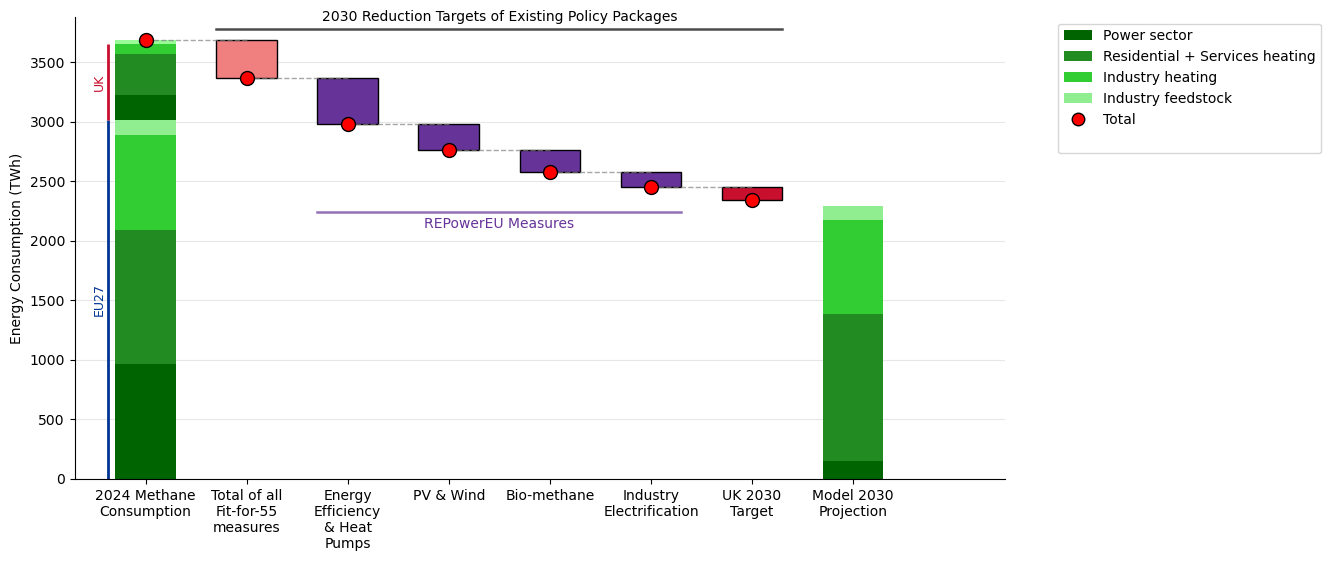

In [75]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
# Define colors for each sector
sector_colors = {
    "Power sector": "#006400",           # Dark green
    "Residential + Services heating": "#228B22",  # Forest green
    "Industry heating": "#32CD32",       # Lime green
    "Industry feedstock": "#90EE90",     # Light green
    "Total": "#98FB98",                  # Pale green
}
country_colors = {
    "UK": "#c80f2e",
    "Norway": "#4682B4",
    "Switzerland": "#DC143C",
    "EU27_2020": "#003494",
}

nice_names = {
    "UK": "UK",
    "Norway": "Norway",
    "Switzerland": "Switzerland",
    "EU27_2020": "EU27",
}

# Create stacked bar plot
bottom = 0
width = 0.6
for _, row in df.iterrows():
    ax.bar(
        0,
        row["value_TWh"],
        bottom=bottom,
        color=sector_colors[row["sector"]],
        # label=row["sector"],
        width=width
    )
    bottom += row["value_TWh"]

by_country = df.groupby("geo")['value_TWh'].sum()
bottom = 0
linewidth = 2
padding = 0.07  # Small padding from the left side of the bar

for name, val in by_country.loc[df.geo.unique()].items():
    # Only draw lines for EU27_2020 and UK
    if name in ['EU27_2020', 'UK']:
        # Draw a vertical line on the left side of the bar
        x_position = - width / 2 - padding
        ax.plot(
            [x_position, x_position],
            [bottom, bottom + val],
            color=country_colors[name],
            linewidth=linewidth,
            solid_capstyle='butt'
        )
        
        # Add text label along the line
        ax.text(
            x_position - 0.02,
            bottom + val / 2,
            nice_names[name],
            rotation=90,
            va='center',
            ha='right',
            fontsize=9,
            color=country_colors[name]
        )
    
    bottom += val

# Add red point for total
total_value = by_country.sum()
ax.scatter(
    0,
    total_value,
    color='red',
    edgecolor='black',
    s=100,
    zorder=5,
    label='Total'
)

x_ticklabels = ["2024 Methane\nConsumption"]

#### Waterfall parts

# First waterfall step: -500 TWh reduction

waterfall_start_tracker = total_value

measures_and_labels = [
    ('Total of all Fit-for-55 measures', 'Total of all\nFit-for-55\nmeasures'),
    ('Energy Efficiency and Heat Pumps', 'Energy\nEfficiency\n& Heat\nPumps'),
    ('PV and wind', 'PV & Wind'),
    ('Sustainable bio-methane', 'Bio-methane'),
    ('Reduced use in industry', 'Industry\nElectrification'),
    ('UK reduction across sectors', 'UK 2030\nTarget')
    # ('Renewable hydrogen (domestic and import)', 'Electrolytic\nHydrogen&\nImports'),
]

for x_pos, (measure_name, nice_label) in enumerate(measures_and_labels):
    
    x_pos = x_pos + 1

    reduction_value = -df_f55_rpe.loc[df_f55_rpe['measure'] == measure_name, 'twh_2030'].values[0]
    start_y = waterfall_start_tracker
    end_y = start_y + reduction_value
    waterfall_start_tracker = end_y

    if x_pos == 1:
        color = 'lightcoral'
    elif x_pos == len(measures_and_labels):
        color = country_colors['UK']
    else:
        color = 'rebeccapurple'

    # Draw the bar for the reduction
    ax.bar(
        x_pos,
        reduction_value,
        bottom=start_y,
        color=color,
        edgecolor='black',
        width=width,
        label='Reduction'
    )

    # Add horizontal line connecting top of first bar to top of second bar
    ax.plot(
        [x_pos - 1, x_pos],
        [start_y, start_y],
        color='gray',
        linestyle='--',
        linewidth=1,
        alpha=0.7
    )

    # Add point for new total at bottom of reduction bar
    ax.scatter(
        x_pos,
        end_y,
        color='red',
        edgecolor='black',
        s=100,
        zorder=5
    )

    x_ticklabels.append(nice_label)

ax.plot(
    [1 - width / 2, len(measures_and_labels) + width / 2],
    [by_country.sum() + 100, by_country.sum() + 100],
    color='black',
    linestyle='-',
    linewidth=1.8,
    alpha=0.7
    )
ax.text(
    0.5 + len(measures_and_labels) / 2,
    by_country.sum() + 200,
    '2030 Reduction Targets of Existing Policy Packages',
    fontsize=10,
    ha='center',
    va='center'
)

ax.plot(
    [2 - width / 2, len(measures_and_labels) - 1 + width / 2],
    [end_y - 100, end_y - 100],
    color='rebeccapurple',
    linestyle='-',
    linewidth=1.8,
    alpha=0.7
    )
ax.text(
    1.5 + (len(measures_and_labels) - 2) / 2,
    end_y - 200,
    'REPowerEU Measures',
    fontsize=10,
    ha='center',
    va='center',
    color='rebeccapurple'
)


# Create stacked bar plot
bottom = 0
width = 0.6
for sector, val in consumption_by_sector_projected_2030.items():
    ax.bar(
        len(measures_and_labels) + 1,
        val,
        bottom=bottom,
        color=sector_colors[sector],
        # label=row["sector"],
        width=width
    )
    bottom += val

x_ticklabels.append('Model 2030\nProjection')





ax.set_ylabel("Energy Consumption (TWh)")
ax.set_xticks(list(range(len(x_ticklabels))))
ax.set_xticklabels(x_ticklabels)

# Create legend handles for sectors only
sector_handles = [plt.Rectangle((0,0),1,1, facecolor=color) for color in sector_colors.values()][:-1]
sector_labels = list(sector_colors.keys())[:-1]

# Add total point to legend
total_handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=9, markeredgecolor='black', label='Total')

# Use sector handles and total handle
all_handles = sector_handles + [total_handle] + [plt.Rectangle((0,0),1,1, facecolor='none', edgecolor='none')]
all_labels = sector_labels + ['Total'] + ['']

ax.legend(all_handles, all_labels, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(-0.7, 8.5)
ax.set_ylim(0, total_value + 200)

plt.show()

##### look page 56 of https://www.neso.energy/document/364541/download regarding UK

In [76]:
####  less in relation to RePowerEU but instead more in relation to the model outputs

In [78]:
n_template = 'base_s_50__{}H-T-H-B-I-A-dist1_{}_{}_{}.nc'

In [79]:
models_shown = [
    (168, '2030', 'NT+freepumps+freepumps', '3000'),
    (168, '2030', 'NT+freepumps+freepumps+h2electrolysis-300', '3000'),
    (168, '2030', 'NT+freepumps+freepumps+h2electrolysis-300+biogastogas-100', '3000'),
    (168, '2030', 'NT+freepumps+freepumps+biogastogas-100', '3000'),
    (168, '2035', 'NT+freepumps+freepumps', '2000'),
    (168, '2035', 'NT+freepumps+freepumps+h2electrolysis-300', '2000'),
    (168, '2035', 'NT+freepumps+freepumps+h2electrolysis-300+biogastogas-100', '2000'),
    (168, '2035', 'NT+freepumps+freepumps+biogastogas-100', '2000'),
]

In [126]:
idx = pd.IndexSlice

def get_model_gas_consumption(n):

    eb = n.statistics.energy_balance()
    gas_balance = eb.loc[idx[:, :, 'gas']]
    gas_balance.index = gas_balance.index.droplevel(0)
    gas_balance = gas_balance.loc[gas_balance < 0].mul(-1e-6)
    
    # Group carriers into sectors
    sector_mapping = {
        "Power sector": [
            "Combined-Cycle Gas",
            "Open-Cycle Gas",
            "urban central gas CHP",
        ],
        "Residential + Services heating": [
            "rural gas boiler",
            "urban central gas boiler",
            "urban decentral gas boiler",
        ],
        "Industry heating": [
            "heat<100 industry gas",
            "heat100-200 industry gas",
            "heat200-500 industry gas",
            "heat>500 industry gas",
        ],
        "Industry feedstock": [
            "SMR",
            "gas DRI",
            "gas for industry",
            "gas for industry CC",
        ],
    }
    
    # Sum carriers by sector
    sector_totals = {}
    for sector, carriers in sector_mapping.items():
        sector_totals[sector] = gas_balance[gas_balance.index.isin(carriers)].sum()
    
    gas_balance_by_sector = pd.Series(sector_totals)
    return gas_balance_by_sector

costs = []

for model in models_shown:

    fn = n_template.format(*model)
    n = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / fn)

    # consumption_by_sector_projected_2030 = get_model_gas_consumption(n)
    # consumption_by_sector_projected_2030
    c = n.statistics.capex().groupby(level=1).sum()
    o = n.statistics.opex().groupby(level=1).sum()
    union = c.index.union(o.index)
    c = c.reindex(union).fillna(0)
    o = o.reindex(union).fillna(0)
    costs.append(c.add(o).rename(fn) / 1e9)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+h2electrolysis-300_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+h2electrolysis-300+biogastogas-100_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+biogastogas-100_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT+freepumps+freepumps_2000.nc has buses, carriers, generators, global_constraints

In [127]:
c = pd.concat(costs, axis=1).replace(np.nan, 0)

carrier
AC                              7.417229
BEV charger                     0.003009
BOF                            13.652089
Battery Storage                11.203001
CO2 pipeline                    0.311641
                                 ...    
forced H2 Electrolysis          0.000000
forced biogas to gas            0.000000
unsustainable biogas            0.000000
unsustainable bioliquids        0.000000
unsustainable solid biomass     0.000000
Name: base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps_3000.nc, Length: 101, dtype: float64
base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+h2electrolysis-300_3000.nc                    0.009858
base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+h2electrolysis-300+biogastogas-100_3000.nc    6.351166
base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+biogastogas-100_3000.nc                       6.320536
dtype: float64
carrier
AC                              7.416928
BEV charger                  

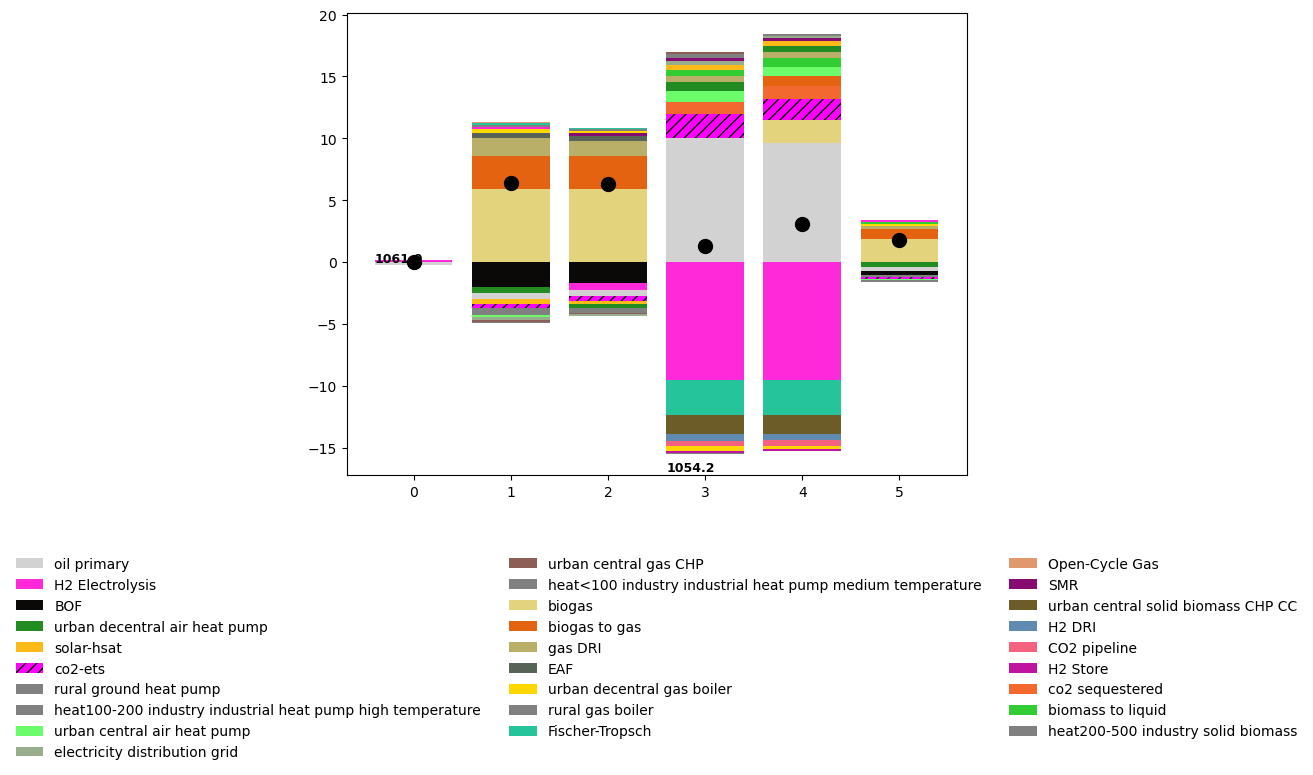

In [131]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

xtracker = 0

for y, con in zip(['2030', '2035'], ['3000', '2000']):

    base = n_template.format('168', y, 'NT+freepumps+freepumps', con)

    ss = c.loc[:, c.columns.str.contains('_' + y + '_')]
    print(ss[base])

    base_cost = ss[base].sum()

    diff = ss.sub(ss[base], axis=0).drop(columns=[base])
    print(diff.sum())

    threshold = 0.1 # 100mn Euro cutoff
    for i, col in enumerate(diff.columns):

        sss = diff[col].loc[diff[col].abs() > threshold]

        # Split into positive and negative values
        positive = sss[sss > 0].sort_values(ascending=False)
        negative = sss[sss < 0].sort_values(ascending=True)

        # Plot negative stack (bottom)
        bottom_neg = 0
        for tech, value in negative.items():
            color = tech_colors.get(tech, 'gray')
            hatch = '///' if tech == 'co2-ets' else None
            ax.bar(xtracker, value, bottom=bottom_neg, color=color, label=tech, width=0.8, hatch=hatch)
            bottom_neg += value

        # Plot positive stack (top)
        bottom_pos = 0
        for tech, value in positive.items():
            color = tech_colors.get(tech, 'gray')
            hatch = '///' if tech == 'co2-ets' else None
            ax.bar(xtracker, value, bottom=bottom_pos, color=color, label=tech, width=0.8, hatch=hatch)
            bottom_pos += value

        # Add point for total difference
        total_diff = diff[col].sum()
        ax.scatter(xtracker, total_diff, color='black', s=100, zorder=10, marker='o')

        # Write base_cost text at bottom left for first column of each year
        if i == 0:
            ax.text(xtracker - 0.4, ax.get_ylim()[0], f'{base_cost:.1f}', 
                   ha='left', va='bottom', fontsize=9, fontweight='bold')

        xtracker += 1

    # Add legend below the plot
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # Remove duplicates
    ax.legend(by_label.values(), by_label.keys(), loc='upper center', 
             bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

plt.show()

In [119]:
c.sum()

base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps_3000.nc                                       1067.224408
base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+h2electrolysis-300_3000.nc                    1060.989348
base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+h2electrolysis-300+biogastogas-100_3000.nc    1067.330656
base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+biogastogas-100_3000.nc                       1067.300026
base_s_50__168H-T-H-B-I-A-dist1_2035_NT+freepumps+freepumps_2000.nc                                       1054.205189
base_s_50__168H-T-H-B-I-A-dist1_2035_NT+freepumps+freepumps+h2electrolysis-300_2000.nc                    1055.507549
base_s_50__168H-T-H-B-I-A-dist1_2035_NT+freepumps+freepumps+h2electrolysis-300+biogastogas-100_2000.nc    1057.250523
base_s_50__168H-T-H-B-I-A-dist1_2035_NT+freepumps+freepumps+biogastogas-100_2000.nc                       1055.963850
dtype: float64

In [122]:
(c['base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps+h2electrolysis-300_3000.nc'] - c['base_s_50__168H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps_3000.nc']).sort_values()

carrier
unsustainable bioliquids      -17.603761
biomass to liquid             -12.081508
unsustainable solid biomass   -11.572657
BOF                            -9.956188
unsustainable biogas           -8.153598
                                 ...    
EAF                             2.310050
solid biomass                   2.810341
gas DRI                         7.251200
co2-ets                        23.909336
oil primary                    37.326551
Length: 101, dtype: float64